What were to total missed pickup by route?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects as so
import re

In [2]:
trash = pd.read_csv('../data/trash_hauler_report.csv')
trash

,Request Number,Date Opened,Request,Description,Incident Address,Zip Code,Trash Hauler,Trash Route,Council District,State Plan X,State Plan Y
0,25270,11/01/17,Trash - Backdoor,"house with the wheel chair ramp, they share dr...",3817 Crouch Dr,37207.0,RED RIVER,3205,2.0,1.727970e+06,686779.478089
1,25274,11/01/17,Trash - Curbside/Alley Missed Pickup,Curb/Trash miss Tuesday.,4028 Clarksville Pike,37218.0,RED RIVER,4202,1.0,1.721259e+06,685444.799565
2,25276,11/01/17,Trash - Curbside/Alley Missed Pickup,Curb/trash miss Tuesday.,6528 Thunderbird Dr,37209.0,RED RIVER,4205,20.0,1.707027e+06,659887.471571
3,25307,11/01/17,Trash - Curbside/Alley Missed Pickup,missed,2603 old matthews rd,37207.0,WASTE IND,2206,2.0,1.735692e+06,685027.245923
4,25312,11/01/17,Trash - Curbside/Alley Missed Pickup,Missed the even side of the road.,604 croley dr,37209.0,RED RIVER,4203,20.0,1.710186e+06,664205.101066
...,...,...,...,...,...,...,...,...,...,...,...
20221,267125,11/01/19,Trash - Curbside/Alley Missed Pickup,MISSED...NEIGHBORS MISSED,2731 Murfreesboro Pike,37013.0,RED RIVER,4502,32.0,1.781137e+06,632448.551144
20222,267126,11/01/19,Trash - Curbside/Alley Missed Pickup,entire alley,"1621 Long Ave, Nashville, TN 37206, United States",37206.0,METRO,9508,6.0,1.749711e+06,669201.601569
20223,267130,11/01/19,Trash - Curbside/Alley Missed Pickup,missed several,"2943 Windemere Cir, Nashville, TN 37214, Unite...",37214.0,RED RIVER,1502,15.0,1.770293e+06,674936.303809
20224,267134,11/01/19,Trash - Curbside/Alley Missed Pickup,Caller stated trash was missed & were only pic...,"3325 Murfreesboro Pike, Nashville, TN 37013, U...",37013.0,RED RIVER,4502,32.0,1.785225e+06,627146.400187


In [3]:
trash['Request '] = trash['Request '].astype('string')
trash['Description'] = trash['Description'].fillna("").str.lower().astype('string')
trash.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20226 entries, 0 to 20225
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Request Number    20226 non-null  int64  
 1   Date Opened       20226 non-null  object 
 2   Request           20226 non-null  string 
 3   Description       20226 non-null  string 
 4   Incident Address  20217 non-null  object 
 5   Zip Code          20151 non-null  float64
 6   Trash Hauler      19325 non-null  object 
 7   Trash Route       19279 non-null  object 
 8   Council District  20177 non-null  float64
 9   State Plan X      20198 non-null  float64
 10  State Plan Y      20198 non-null  float64
dtypes: float64(4), int64(1), object(4), string(2)
memory usage: 1.7+ MB


In [4]:
trashm = trash.loc[
    (trash['Description'].str.contains('miss') == True) |
    (trash['Request '].str.contains('Missed') == True)]
trashm

,Request Number,Date Opened,Request,Description,Incident Address,Zip Code,Trash Hauler,Trash Route,Council District,State Plan X,State Plan Y
1,25274,11/01/17,Trash - Curbside/Alley Missed Pickup,curb/trash miss tuesday.,4028 Clarksville Pike,37218.0,RED RIVER,4202,1.0,1.721259e+06,685444.799565
2,25276,11/01/17,Trash - Curbside/Alley Missed Pickup,curb/trash miss tuesday.,6528 Thunderbird Dr,37209.0,RED RIVER,4205,20.0,1.707027e+06,659887.471571
3,25307,11/01/17,Trash - Curbside/Alley Missed Pickup,missed,2603 old matthews rd,37207.0,WASTE IND,2206,2.0,1.735692e+06,685027.245923
4,25312,11/01/17,Trash - Curbside/Alley Missed Pickup,missed the even side of the road.,604 croley dr,37209.0,RED RIVER,4203,20.0,1.710186e+06,664205.101066
7,25327,11/01/17,Trash Collection Complaint,"trash out on time, miss again tuesday. alley",1816 Jo Johnston Ave,37203.0,METRO,9208,21.0,1.731459e+06,666013.601229
...,...,...,...,...,...,...,...,...,...,...,...
20221,267125,11/01/19,Trash - Curbside/Alley Missed Pickup,missed...neighbors missed,2731 Murfreesboro Pike,37013.0,RED RIVER,4502,32.0,1.781137e+06,632448.551144
20222,267126,11/01/19,Trash - Curbside/Alley Missed Pickup,entire alley,"1621 Long Ave, Nashville, TN 37206, United States",37206.0,METRO,9508,6.0,1.749711e+06,669201.601569
20223,267130,11/01/19,Trash - Curbside/Alley Missed Pickup,missed several,"2943 Windemere Cir, Nashville, TN 37214, Unite...",37214.0,RED RIVER,1502,15.0,1.770293e+06,674936.303809
20224,267134,11/01/19,Trash - Curbside/Alley Missed Pickup,caller stated trash was missed & were only pic...,"3325 Murfreesboro Pike, Nashville, TN 37013, U...",37013.0,RED RIVER,4502,32.0,1.785225e+06,627146.400187


In [5]:
trashm.loc[:, 'Trash Route'] = trashm['Trash Route'].astype('string')
trasho = trashm.loc[trashm['Trash Route'] == '2206']
trasho

,Request Number,Date Opened,Request,Description,Incident Address,Zip Code,Trash Hauler,Trash Route,Council District,State Plan X,State Plan Y
3,25307,11/01/17,Trash - Curbside/Alley Missed Pickup,missed,2603 old matthews rd,37207.0,WASTE IND,2206,2.0,1.735692e+06,685027.245923
369,29524,11/22/17,Trash - Curbside/Alley Missed Pickup,seems the whole street missed {trash} curb. sh...,2705 Combs Dr,37207.0,WASTE IND,2206,2.0,1.735119e+06,686591.116119
452,30822,11/30/17,Trash - Curbside/Alley Missed Pickup,"curb/trash miss for pickup, 2 carts out.",314 Prince Ave B,37207.0,WASTE IND,2206,5.0,1.743874e+06,682610.621859
612,32944,12/12/17,Trash - Curbside/Alley Missed Pickup,missed pick up but picked up neighbors. caller...,519 yokley rd,37207.0,WASTE IND,2206,2.0,1.735186e+06,685173.230807
780,35000,12/26/17,Trash - Curbside/Alley Missed Pickup,trash was not picked up,430 e trinity ln b,37207.0,WASTE IND,2206,5.0,1.744747e+06,682158.063623
...,...,...,...,...,...,...,...,...,...,...,...
15635,223092,07/31/19,Trash - Curbside/Alley Missed Pickup,entire street missed,"1206 Avondale Cir, Nashville, TN 37207, United...",37207.0,WASTE IND,2206,2.0,1.738305e+06,683641.850176
17901,242675,09/05/19,Trash - Curbside/Alley Missed Pickup,missed,"2656 Combs Dr, Nashville, TN 37207, United States",37207.0,WASTE IND,2206,2.0,1.735149e+06,686377.071701
18534,251310,09/25/19,Trash - Curbside/Alley Missed Pickup,"no one pick up tuesday/on their side, curb {why?}","2816 Old Matthews Rd, Nashville, TN 37207, Uni...",37207.0,WASTE IND,2206,2.0,1.734177e+06,686448.799705
18634,252421,09/27/19,Trash - Curbside/Alley Missed Pickup,wants a supervisor to call her tired of having...,"2816 Old Matthews Rd, Nashville, TN 37207, Uni...",37207.0,WASTE IND,2206,2.0,1.734177e+06,686448.799705


In [6]:
trashr = trashm.value_counts('Trash Route').to_frame().reset_index()

In [7]:
trashr

,Trash Route,count
0,4504,329
1,3302,291
2,4404,255
3,9303,245
4,1303,240
...,...,...
167,2405S,3
168,4201S,2
169,2505S,2
170,3303S,2


In [8]:
trasha = pd.merge(trashr, trashm, left_on="Trash Route", right_on="Trash Route", how="left")
trasha

,Trash Route,count,Request Number,Date Opened,Request,Description,Incident Address,Zip Code,Trash Hauler,Council District,State Plan X,State Plan Y
0,4504,329,25941,11/03/17,Trash Collection Complaint,missed again. has had multiple issues with the...,1300 Rural Hill Rd,37013.0,RED RIVER,32.0,1.777932e+06,628763.202134
1,4504,329,26141,11/06/17,Trash Collection Complaint,trash missed almost every week - adv client to...,5550 Mt View Rd,37013.0,RED RIVER,32.0,1.780680e+06,622557.601894
2,4504,329,28863,11/17/17,Trash - Curbside/Alley Missed Pickup,they skipped my house for trash pickup,605 Welshcrest Pl,37013.0,RED RIVER,32.0,1.776990e+06,632123.549540
3,4504,329,29146,11/20/17,Trash - Curbside/Alley Missed Pickup,missed. states has been missed twice in two we...,1312 Rice Hill Cir,37013.0,RED RIVER,32.0,1.779104e+06,631484.695500
4,4504,329,30044,11/27/17,Trash - Curbside/Alley Missed Pickup,missed pick up - others missed in area,760 PIPPIN DR,37013.0,RED RIVER,28.0,1.775550e+06,629604.762170
...,...,...,...,...,...,...,...,...,...,...,...,...
16967,2505S,2,55929,03/23/18,Trash - Curbside/Alley Missed Pickup,cart still out,2721 smith springs rd,37217.0,RED RIVER,29.0,1.783988e+06,639863.867987
16968,2505S,2,233039,08/16/19,Trash - Curbside/Alley Missed Pickup,"curb trash/missed friday, why did they take ot...","1141 Nashboro Blvd, Nashville, TN 37217, Unite...",37217.0,RED RIVER,29.0,1.779825e+06,639719.043450
16969,3303S,2,27234,11/09/17,Trash - Curbside/Alley Missed Pickup,trash missed pick up please note if resident ...,68 ravenwood hills cir,37215.0,RED RIVER,25.0,1.728043e+06,640999.191433
16970,3303S,2,64993,05/03/18,Trash - Curbside/Alley Missed Pickup,missed trash pickup,68 ravenwood hills cir,37215.0,RED RIVER,25.0,1.728042e+06,641001.685859


In [9]:
trashu = trashm[['Trash Hauler', 'Trash Route']]
trashu = trashu.sort_values(by='Trash Route', ascending=False)
trashu['Trash Hauler'].isnull().sum()
trashu['Trash Route'].isnull().sum()
trashb = trashu[trashu['Trash Route'].isna() == False]
trashb

,Trash Hauler,Trash Route
7915,METRO,9508
1908,METRO,9508
1943,METRO,9508
1931,METRO,9508
6919,METRO,9508
...,...,...
1156,RED RIVER,1201
6652,RED RIVER,1201
19321,RED RIVER,1201
19322,RED RIVER,1201


In [10]:
trashb.value_counts('Trash Hauler').sum()

16939

In [11]:
trashb.value_counts('Trash Route').sum()

16972

In [12]:
trashb['Trash Hauler'].isna().sum()

33

In [13]:
trashb

,Trash Hauler,Trash Route
7915,METRO,9508
1908,METRO,9508
1943,METRO,9508
1931,METRO,9508
6919,METRO,9508
...,...,...
1156,RED RIVER,1201
6652,RED RIVER,1201
19321,RED RIVER,1201
19322,RED RIVER,1201


In [14]:
trashg = trashb.value_counts('Trash Route').to_frame().reset_index()

In [15]:
trashg

,Trash Route,count
0,4504,329
1,3302,291
2,4404,255
3,9303,245
4,1303,240
...,...,...
167,2405S,3
168,4201S,2
169,2505S,2
170,3303S,2


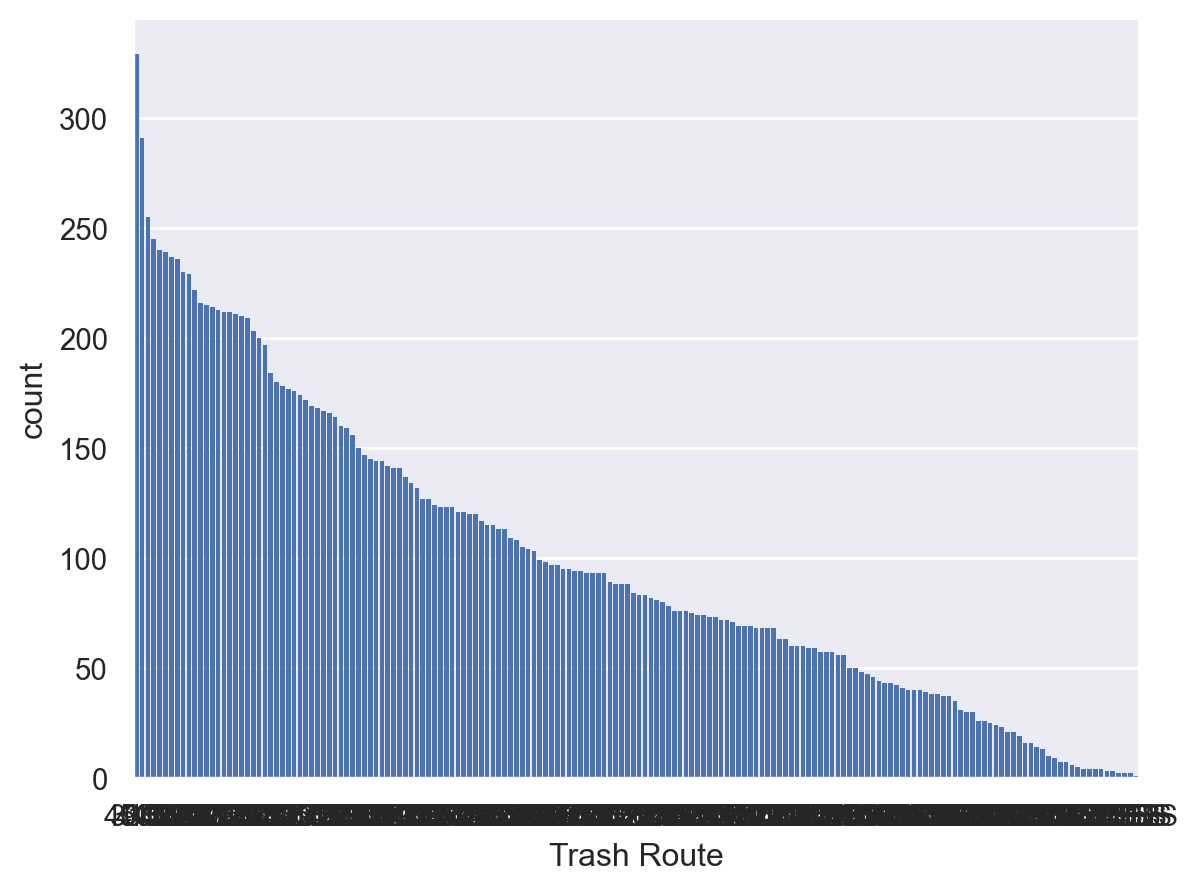

In [16]:
so.Plot(trashg, x="Trash Route", y="count").add(so.Bar())

In [21]:
trashq = pd.merge(trashg, trashm, left_on=['Trash Route'], right_on=['Trash Route'], how="left")
trashq

,Trash Route,count,Request Number,Date Opened,Request,Description,Incident Address,Zip Code,Trash Hauler,Council District,State Plan X,State Plan Y
0,4504,329,25941,11/03/17,Trash Collection Complaint,missed again. has had multiple issues with the...,1300 Rural Hill Rd,37013.0,RED RIVER,32.0,1.777932e+06,628763.202134
1,4504,329,26141,11/06/17,Trash Collection Complaint,trash missed almost every week - adv client to...,5550 Mt View Rd,37013.0,RED RIVER,32.0,1.780680e+06,622557.601894
2,4504,329,28863,11/17/17,Trash - Curbside/Alley Missed Pickup,they skipped my house for trash pickup,605 Welshcrest Pl,37013.0,RED RIVER,32.0,1.776990e+06,632123.549540
3,4504,329,29146,11/20/17,Trash - Curbside/Alley Missed Pickup,missed. states has been missed twice in two we...,1312 Rice Hill Cir,37013.0,RED RIVER,32.0,1.779104e+06,631484.695500
4,4504,329,30044,11/27/17,Trash - Curbside/Alley Missed Pickup,missed pick up - others missed in area,760 PIPPIN DR,37013.0,RED RIVER,28.0,1.775550e+06,629604.762170
...,...,...,...,...,...,...,...,...,...,...,...,...
16967,2505S,2,55929,03/23/18,Trash - Curbside/Alley Missed Pickup,cart still out,2721 smith springs rd,37217.0,RED RIVER,29.0,1.783988e+06,639863.867987
16968,2505S,2,233039,08/16/19,Trash - Curbside/Alley Missed Pickup,"curb trash/missed friday, why did they take ot...","1141 Nashboro Blvd, Nashville, TN 37217, Unite...",37217.0,RED RIVER,29.0,1.779825e+06,639719.043450
16969,3303S,2,27234,11/09/17,Trash - Curbside/Alley Missed Pickup,trash missed pick up please note if resident ...,68 ravenwood hills cir,37215.0,RED RIVER,25.0,1.728043e+06,640999.191433
16970,3303S,2,64993,05/03/18,Trash - Curbside/Alley Missed Pickup,missed trash pickup,68 ravenwood hills cir,37215.0,RED RIVER,25.0,1.728042e+06,641001.685859


In [22]:
trashq=trashq[trashq['Trash Route'].isna() == False]
trashq['Trash Route'].isna().sum()

0

In [25]:
trashq['Trash Hauler'] = trashq['Trash Hauler'].str.upper()

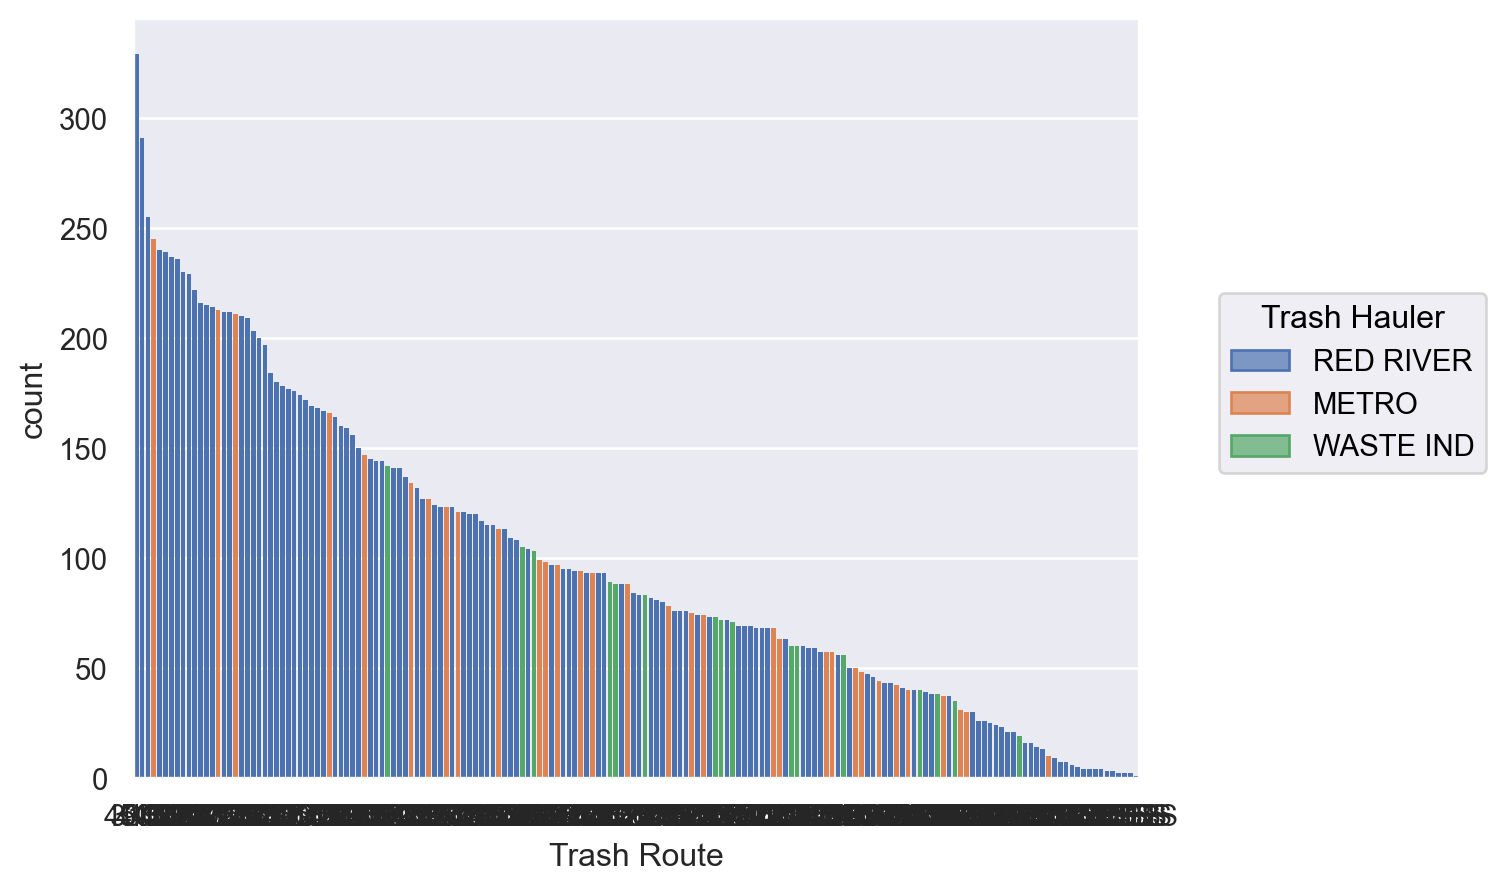

In [29]:
so.Plot(trashq, x="Trash Route", y="count", color="Trash Hauler").add(so.Bar())